# MOD 4 - Deep Learning con YOLOv5-nano Fine-tuning

## Progetto: Minecraft mob detection
## Autore: Aiman Hamdouni

Qui l'obiettivo è il fine-tuning di YOLOv5-nano sul dataset Minecraft per object detection, e confronto con la pipeline classica HOG+SVM.

YOLOv5-nano perchè?
- Nano è il modello più leggero della famiglia (funziona meglio con google colab)
- Pre-trained su COCO (80 classi) => transfer learning su 4 classi Minecraft

---

## 1. Setup librerie (REVISIONATO)

- PROBLEMA? Training di CNN profonde da zero richiede dataset enormi e risorse massicce.
- SOLUZIONE? è il Transfer Learning prendiamo un modello già addestrato su un dataset grande (COCO, 330K immagini, 80 classi) e lo adattiamo al nostro task specifico (4 classi di mob Minecraft).

- PERCHE FUNZION?
Le CNN imparano gerarchie di feature:
1. Layer bassi => feature generiche (bordi, texture)  => riutilizzabili ovunque
2. Layer alti  => feature specifiche del task (parti di oggetti)
Le feature low-level di COCO sono utili anche per rilevare mob Minecraft

In [10]:
# os e' una libreria standard di python per interagire col sistema operativo
# qui la uso per controllare se una cartella esiste gia sul disco
import os

# os.path.exists() ritorna True se il percorso esiste, False se non esiste
if not os.path.exists('yolov5'):
    # la cartella non c'e' => devo scaricare yolov5 da github
    # git clone copia l'intero repository (codice sorgente, script, modelli)
    !git clone https://github.com/ultralytics/yolov5.git

    # %cd e' un comando speciale di jupyter notebook ("magic command")
    # cambia la cartella di lavoro corrente
    # da qui in poi tutti i percorsi relativi partono da yolov5/
    %cd yolov5

    # installo le librerie python che yolov5 richiede per funzionare
    # -q significa "quiet" => non stampa tutto il dettaglio dell'installazione
    # -r requirements.txt dice a pip di leggere la lista dal file
    !pip install -q -r requirements.txt
else:
    # la cartella esiste gia (magari ho gia eseguito questa cella prima)
    # quindi mi basta entrarci senza dover riscaricare tutto
    %cd yolov5

print("YOLOv5 installato correttamente")

# verifico che pytorch funzioni e che veda la GPU
# CUDA e' la tecnologia NVIDIA che permette di fare calcoli sulla GPU
# senza GPU il training richiederebbe ore invece di minuti
!python -c "import torch; print(f'PyTorch {torch.__version__}, CUDA {torch.cuda.is_available()}')"

Cloning into 'yolov5'...
remote: Enumerating objects: 18375, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 18375 (delta 39), reused 20 (delta 20), pack-reused 18310 (from 2)
Receiving objects: 100% (18375/18375), 17.47 MiB | 19.42 MiB/s, done.
Resolving deltas: 100% (12485/12485), done.
/content/yolov5/yolov5
YOLOv5 installato correttamente
PyTorch 2.11.0+cu128, CUDA True


In [11]:
# GESTISCO LA PARTE DI CARICAMENTO LIBRERIE

# kagglehub mi serve per scaricare dataset direttamente da kaggle
# senza doverli scaricare a mano dal sito web
!pip install kagglehub

import kagglehub                      # per scaricare il dataset da kaggle
import cv2                            # OpenCV => per leggere, manipolare e disegnare su immagini
import numpy as np                    # NumPy => le immagini in python sono array numpy (matrici di numeri)
import matplotlib.pyplot as plt       # Matplotlib => per creare grafici e visualizzare immagini
import matplotlib.patches as patches  # patches => per disegnare rettangoli (bounding box) sopra le immagini
from pathlib import Path              # Path => gestisce i percorsi dei file in modo comodo
                                      # esempio => Path("/cartella") / "sottocartella" / "file.txt"
                                      # funziona sia su Windows (\) che su Linux (/)
from collections import Counter       # Counter => conta quante volte appare ogni elemento in una lista
import random                         # per scegliere elementi casuali (servira per campionare immagini)
import yaml as yaml_lib               # yaml => formato file per le configurazioni (lo usa yolov5)
from models.yolo import Model         # classe Model di yolov5 (per ispezionare l'architettura)
import yaml                           # un altro import di yaml (lo uso per scrivere il data.yaml)
import torch                          # PyTorch => il framework di deep learning usato da yolov5
import shutil                         # È una libreria standard di Python che serve per copiare, spostare e cancellare file e cartelle

# GESTISCO LA PARTE DEI PERCORSI (PATH)

# kagglehub.dataset_download scarica il dataset e ritorna il percorso dove lo ha salvato
percorso_dataset = kagglehub.dataset_download("dracotlw/minecraft-mobs-yolo-dataset")

# Path() crea un oggetto percorso, l'operatore / lo concatena con le sottocartelle
cartella_dataset = Path(percorso_dataset) / "minecraft_mobs_yolo"

# su kaggle la cartella di input e' in sola lettura quindi copio il dataset
# in una cartella scrivibile, cosi posso modificare le etichette dopo
cartella_copia = Path('/kaggle/working/minecraft_mobs_yolo')
if not cartella_copia.exists():
    shutil.copytree(str(cartella_dataset), str(cartella_copia))
cartella_dataset = cartella_copia

cartella_immagini_train = cartella_dataset / "train" / "images"
cartella_immagini_val = cartella_dataset / "val" / "images"
cartella_etichette_train = cartella_dataset / "train" / "labels"
cartella_etichette_val = cartella_dataset / "val" / "labels"

print("\nVERIFICA SE CI SONO I PERCORSI SALVATI")
print(cartella_immagini_train)
print(cartella_immagini_val)

Using Colab cache for faster access to the 'minecraft-mobs-yolo-dataset' dataset.

VERIFICA SE CI SONO I PERCORSI SALVATI
/kaggle/working/minecraft_mobs_yolo/train/images
/kaggle/working/minecraft_mobs_yolo/val/images


## 2. Setup dataset (REVISIONATO)

YOLOv5 richiede un file data.yaml che descrive:
- Il percorso delle immagini train/val
- Il numero di classi
- I nomi delle classi

In [12]:
# creo un dizionario python con le informazioni che yolov5 ha bisogno di sapere sul dataset
# yolov5 leggera questo file per trovare le immagini e sapere quante classi ci sono
configurazione_dati = {
    'path': str(cartella_dataset), # cartella radice del dataset
    'train': str(cartella_immagini_train),  # dove stanno le immagini di training
    'val': str(cartella_immagini_val),  # dove stanno le immagini di validazione
    'nc': 4,   # nc = number of classes => 4 classi nel nostro caso
    'names': ['creeper', 'skeleton', 'spider', 'zombie']  # i nomi che corrispondono agli id 0, 1, 2, 3
}

# scrivo il dizionario in formato YAML (un formato testuale per configurazioni)
# yaml e' piu leggibile di JSON perche usa indentazione al posto delle parentesi
percorso_yaml = 'minecraft_mobs.yaml'
file_yaml = open(percorso_yaml, 'w') # apro il file in modalita scrittura ('w' = write)
yaml.dump(configurazione_dati, file_yaml, default_flow_style=False)  # converto il dizionario in yaml
file_yaml.close() # chiudo il file per salvare le modifiche

print(f"data.yaml salvato in => {percorso_yaml}")

# rileggo il file per verificare che il contenuto sia corretto
print("\nContenuto del file =>")
file_yaml = open(percorso_yaml, 'r')# apro in lettura ('r' = read)
print(file_yaml.read())  # stampo tutto il contenuto
file_yaml.close()

data.yaml salvato in => minecraft_mobs.yaml

Contenuto del file =>
names:
- creeper
- skeleton
- spider
- zombie
nc: 4
path: /kaggle/working/minecraft_mobs_yolo
train: /kaggle/working/minecraft_mobs_yolo/train/images
val: /kaggle/working/minecraft_mobs_yolo/val/images



## 3. Architettura YOLOv5-nano (REVISIONATO)

Per capire come funziona YOLO, bisogna prima sapere come sono fatte le CNN (Convolutional Neural Networks).

Una CNN e' composta da diversi tipi di layer impilati uno dopo l'altro:

1. Convolutional layers => sono dei piccoli filtri (ad esempio 3x3 pixel) che scorrono su tutta l'immagine. Ogni filtro impara a riconoscere un pattern specifico, come un bordo, una texture o una forma. Il risultato si chiama "feature map", cioe' una mappa che evidenzia dove quel pattern appare nell'immagine.

2. Pooling layers => servono a ridurre la dimensione delle feature map. Ad esempio un MaxPool 2x2 prende ogni blocco di 4 pixel e tiene solo il valore piu' alto, dimezzando altezza e larghezza. Questo rende la rete piu' veloce e la aiuta a generalizzare.

3. Activation (ReLU) => e' una funzione semplicissima che vale max(0, x). Se il valore e' positivo lo lascia cosi', se e' negativo lo mette a zero. Serve a introdurre non-linearita', cioe' a permettere alla rete di imparare relazioni complesse tra i pixel.

4. Receptive Field => man mano che si va in profondita' nella rete, ogni neurone "vede" una porzione sempre piu' grande dell'immagine originale. I layer iniziali riconoscono dettagli piccoli (bordi, angoli), quelli profondi riconoscono oggetti interi (un mob, una faccia, un'auto).

L'architettura di YOLO e' divisa in tre blocchi principali:

1. Backbone (CSPDarknet) => e' la parte che guarda l'immagine e ne estrae le feature. Funziona come una serie di filtri sempre piu' sofisticati. Nel nostro caso il backbone e' gia' pre-addestrato su COCO, quindi sa gia' riconoscere forme e texture generiche.

2. Neck (PANet, Feature Pyramid) => prende le feature estratte dal backbone a diverse risoluzioni e le fonde insieme. Questo e' importante perche' un mob piccolo e lontano ha bisogno di feature ad alta risoluzione, mentre un mob grande e vicino ha bisogno di feature a bassa risoluzione. Il neck combina entrambe.

3. Head (Detection Head) => e' la parte finale che produce le predizioni vere e proprie. Per ogni zona dell'immagine dice "qui c'e' un oggetto, e' di questa classe, con questo livello di sicurezza, e il suo rettangolo e' questo". Nel nostro caso la head viene adattata da 80 classi (COCO) a 4 classi (creeper, skeleton, spider, zombie).

Dopo la head, la NMS (Non-Maximum Suppression) elimina i box duplicati e tiene solo le detection migliori.

YOLOv5-nano ha circa 1.9M di parametri, contro i 138M di VGG16. E' cosi' leggero perche' usa dei moltiplicatori ridotti (depth e width multiplier) che rimpiccioliscono ogni layer della rete.

L'immagine entra nella rete con dimensione 640x640x3 (larghezza x altezza x 3 canali RGB)

----------------------------

FLOW?

Primo blocco => BACKBONE (CSPDarknet)

Estrae le feature dall'immagine passando attraverso Conv, BN, SiLU e blocchi residuali.
E' pre-addestrato su COCO quindi le feature generiche sono gia' apprese.

- Conv (Convoluzione) => un filtro che scorre sull'immagine e impara a riconoscere pattern   come bordi, angoli o texture. Ogni filtro produce una "feature map".
- BN (Batch Normalization) => normalizza i valori tra un layer e l'altro per rendere   il training piu' stabile e veloce. Senza BN i numeri potrebbero diventare troppo grandi o troppo piccoli e la rete faticherebbe a imparare.
- SiLU (Sigmoid Linear Unit) => e' la funzione di attivazione usata da YOLOv5.Funziona come ReLU ma e' piu' morbida, cioe' non taglia a zero i valori negativi
in modo netto ma li attenua gradualmente.
- Blocchi residuali => sono gruppi di layer con una "scorciatoia" che collega
l'input direttamente all'output. Servono a evitare che la rete "dimentichi" le informazioni dei layer precedenti quando diventa molto profonda.

Secondo blocco => NECK (FPN + PAN, detto PANet)

Fonde le feature a diverse scale. Feature piccole (80x80) servono per trovare oggetti grandi. Feature medie (40x40) e grandi (20x20) servono per trovare oggetti piccoli.

- FPN (Feature Pyramid Network) => prende le feature dai vari livelli del backbone e le passa dal basso verso l'alto, cosi' i livelli con poca risoluzione ricevono dettagli dai livelli con alta risoluzione.
- PAN (Path Aggregation Network) => fa il percorso inverso, dall'alto verso il basso,cosi' anche i livelli ad alta risoluzione ricevono informazioni "di contesto" dai livelli profondi. Insieme, FPN e PAN permettono di trovare sia oggetti piccoli che grandi nella stessa immagine.

Terzo blocco => HEAD (Detection Head, 3 scale)

Produce le predizioni finali. Da adattare alle nostre 4 classi. Per ogni cella della griglia predice posizione (x, y, w, h), objectness e classe.

- La griglia divide l'immagine in tante celle. Ogni cella e' responsabile di
  predire gli oggetti che hanno il centro in quella zona.
- Objectness => un valore tra 0 e 1 che indica quanto il modello e' sicuro che in quella cella ci sia davvero un oggetto e non solo sfondo.
- x, y, w, h => sono le coordinate del bounding box predetto. (x, y) e' il centro del rettangolo, (w, h) sono larghezza e altezza.

Infine => NMS (Non-Maximum Suppression).

Elimina i box duplicati e tiene solo le detection migliori.
Spesso il modello trova lo stesso oggetto piu' volte con rettangoli leggermente
diversi. NMS confronta tutti i box che si sovrappongono e tiene solo quello
con la confidenza piu' alta, scartando gli altri. Cosi' ogni oggetto viene
rilevato una volta sola.

In [13]:
# voglio capire com'e' strutturato il modello yolov5-nano

# leggo il file YAML che descrive l'architettura della rete
# questo file dice quanti layer ci sono, quanti filtri, ecc.
file_config = open('models/yolov5n.yaml', 'r')
configurazione_modello = yaml_lib.safe_load(file_config)  # safe_load converte yaml in dizionario python
file_config.close()

# depth_multiple e width_multiple sono i "moltiplicatori" che rendono il modello piu leggero
# depth_multiple controlla quanti layer ci sono (0.33 = un terzo rispetto al modello pieno)
# width_multiple controlla quanti filtri ha ogni layer (0.25 = un quarto)
# valori piu piccoli = modello piu leggero e veloce, ma potenzialmente meno preciso
print("YOLOv5-nano e le sue configurazioni")
print(f"Depth multiple => {configurazione_modello.get('depth_multiple', 'N/A')}")
print(f"Width multiple => {configurazione_modello.get('width_multiple', 'N/A')}")
print(f"(valori piccoli = modello piu leggero)")

# carico il modello nano gia pre-addestrato sul dataset COCO
# COCO e' un dataset enorme con 330k immagini e 80 classi di oggetti comuni
# pretrained=True significa che i pesi sono gia allenati (non sono numeri casuali) quindi sarà
# utile per il pretraining
modello = torch.hub.load('ultralytics/yolov5', 'yolov5n', pretrained=True)

# conto quanti parametri ha la rete in totale
# i "parametri" sono tutti i numeri (pesi e bias) che la rete ha imparato
# p.numel() ritorna quanti numeri ci sono in ogni blocco di parametri
parametri_totali = 0
for p in modello.model.parameters():
    parametri_totali = parametri_totali + p.numel()

# provo a contare i parametri allenabili
# requires_grad = True vuol dire che pytorch calcolera il gradiente per quel parametro
# cioe quel parametro verra aggiornato durante il training
parametri_allenabili = 0
for p in modello.model.parameters():
    if p.requires_grad:
        parametri_allenabili = parametri_allenabili + p.numel()

# Qui parametri_allenabili risulta 0 perche torch.hub.load carica il modello
# in modalita inferenza (solo per fare predizioni, non per allenare)
# in questa modalita tutti i gradienti sono spenti per risparmiare memoria
# quando si lancia il training vero con train.py, yolov5 li riattiva automaticamente
# quindi nella pratica TUTTI i parametri vengono allenati durante il fine-tuning

print(f"\nParametri")
print(f"Totali => {parametri_totali:,}")        # :, aggiunge i puntini delle migliaia
print(f"Allenabili => {parametri_allenabili:,}  (0 perche siamo in modalita inferenza)")
print(f"\nPer confronto")
print(f"VGG16 => 138,000,000 parametri")
print(f"ResNet50 => 25,000,000 parametri")
print(f"YOLOv5-nano => {parametri_totali:,} parametri  => scegliamo questo perche e' molto piu leggero")

YOLOv5-nano e le sue configurazioni
Depth multiple => 0.33
Width multiple => 0.25
(valori piccoli = modello piu leggero)


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 v7.0-506-g0675a31b Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

100%|██████████| 3.87M/3.87M [00:00<00:00, 94.2MB/s]

Fusing layers... 
YOLOv5n summary: 213 layers, 1867405 parameters, 0 gradients, 4.5 GFLOPs
Adding AutoShape... 



Parametri
Totali => 1,867,405
Allenabili => 0  (0 perche siamo in modalita inferenza)

Per confronto
VGG16 => 138,000,000 parametri
ResNet50 => 25,000,000 parametri
YOLOv5-nano => 1,867,405 parametri  => scegliamo questo perche e' molto piu leggero


- Fusing layers => YOLOv5 unisce automaticamente alcuni layer adiacenti (ad esempio Conv + BatchNorm) in un unico layer per velocizzare l'esecuzione. Non cambia i risultati.

- 213 layers => il modello originale COCO ha 213 layer (più dei 157 del modello dopo il fine-tuning, perché la head per 80 classi è più grande di quella per 4 classi).

- 1,867,405 parameters => il numero totale di pesi che la rete ha imparato. Ogni parametro è un numero che è stato ottimizzato durante il training su COCO.

- 0 gradients => il modello è stato caricato con torch.hub.load in modalità inferenza, quindi i gradienti sono spenti. Per questo sotto vedi "Allenabili => 0". Questo non è un problema perché quando si lancia il training vero con train.py, YOLOv5 li riattiva automaticamente.

- 4.5 GFLOPs => il numero di operazioni matematiche per processare un'immagine. È pochissimo, il che rende YOLOv5-nano molto veloce.

## 4. Training: Fine-tuning su Minecraft Mobs (NON RIFARE IL TRAINING NECESSITA DI TROPO TEMPO) (REVISIONATO)

Il fine-tuning e' la strategia che usiamo per adattare un modello gia' addestrato (su COCO, 80 classi) al nostro task specifico (4 classi di mob Minecraft). Invece di allenare la rete da zero, partiamo da un modello che sa gia' riconoscere forme e oggetti generici e gli insegniamo a riconoscere i nostri mob.

Il processo si divide in due fasi =>

1. Feature Extraction (primi N epochs) => il backbone viene "congelato", cioe' i suoi pesi non vengono modificati. Si allena solo la detection head, che impara a usare le feature gia' apprese dal backbone per distinguere le nostre 4 classi.

2. Fine-tuning (restanti epochs) => il backbone viene "scongelato" e tutta la rete viene allenata insieme, ma con un learning rate molto basso. Questo permette di adattare anche le feature di basso livello al dominio Minecraft (pixel art, colori a blocchi, ombre particolari) senza distruggere quello che il modello ha gia' imparato su COCO.

La loss function di YOLOv5 e' composta da tre parti, ognuna misura un tipo di errore diverso =>

1. Box loss (CIoU) => misura quanto il rettangolo predetto e' lontano da quello reale. CIoU tiene conto sia della sovrapposizione tra i due box, sia della distanza tra i centri, sia della differenza di forma. Piu' il box e' preciso, piu' questa loss scende.

2. Objectness loss (BCE) => misura quanto il modello e' bravo a capire se in una zona dell'immagine c'e' un oggetto oppure solo sfondo. BCE sta per Binary Cross Entropy, una funzione che penalizza le risposte sbagliate su domande si/no (c'e' un oggetto qui? si o no?).

3. Classification loss (BCE) => misura quanto il modello e' bravo a indovinare la classe giusta. Funziona come l'objectness ma per ogni classe separatamente (e' un creeper? si/no. e' uno skeleton? si/no. e cosi' via).

- L'optimizer e' SGD (Stochastic Gradient Descent) con momentum a 0.937. Il momentum aiuta l'optimizer a non restare bloccato in minimi locali, dandogli una specie di "inerzia" nella direzione giusta.
- Il weight decay (0.0005) e' una forma di regolarizzazione che penalizza i pesi troppo grandi per evitare overfitting.
- YOLOv5 include anche un warm-up nei primi 3 epochs, dove il learning rate parte bassissimo e sale gradualmente, per evitare che la rete faccia aggiornamenti troppo bruschi all'inizio quando i gradienti sono ancora instabili. Dopo il warm-up usa un cosine annealing scheduler che riduce il learning rate lentamente seguendo una curva a coseno, cosi' verso la fine del training il modello fa aggiustamenti sempre piu' piccoli e precisi.

YOLOv5 applica automaticamente diverse tecniche di Data Augmentation =>

1. Mosaic => combina 4 immagini diverse in una sola immagine. Cosi' il modello vede piu' oggetti e contesti diversi in ogni singolo batch, il che migliora la generalizzazione.

2. HSV augmentation => modifica casualmente tonalita' (H), saturazione (S) e luminosita' (V) dell'immagine. Cosi' il modello impara a riconoscere i mob anche con condizioni di luce diverse.

3. Flip orizzontale (p=0.5) => con probabilita' del 50% l'immagine viene specchiata orizzontalmente. Cosi' il modello impara che un mob puo' guardare sia a destra che a sinistra.

4. Scale e translate => l'immagine viene ingrandita/rimpicciolita o spostata casualmente. Cosi' il modello impara a trovare i mob anche quando sono a distanze o posizioni diverse.

Queste augmentation non creano nuove immagini su disco, vengono applicate durante il training su ogni batch.

In [14]:
# PULIZIA DELLE ETICHETTE ----------------------------------------------------------
# nel formato YOLO ogni file .txt contiene una riga per ogni oggetto nell'immagine
# ogni riga ha questo formato =>
#   classe  x_centro  y_centro  larghezza  altezza
# tutti i valori sono normalizzati tra 0 e 1 (coordinate relative all'immagine)
#
# PROBLEMA => in alcuni file ci sono righe con classe = 4 o superiore
# ma noi abbiamo solo 4 classi (0=creeper, 1=skeleton, 2=spider, 3=zombie)
# se non le rimuovo yolov5 dara errore ("Label class 4 exceeds nc=4")

numero_classi = 4  # le classi valide vanno da 0 a 3
contatore_righe_rimosse = 0
contatore_file_modificati = 0

# metto le due cartelle di etichette in una lista cosi le scorro con un unico ciclo
cartelle_etichette = [cartella_etichette_train, cartella_etichette_val]

for cartella in cartelle_etichette:
    # glob("*.txt") cerca tutti i file che finiscono con .txt nella cartella
    file_etichette = sorted(cartella.glob("*.txt"))

    for file_txt in file_etichette:
        # .read_text() legge tutto il contenuto del file come stringa
        # .strip() rimuove spazi e a-capo all'inizio e alla fine
        contenuto = file_txt.read_text().strip()

        # se il file e' vuoto lo salto (immagine senza annotazioni, solo sfondo)
        if contenuto == "":
            continue

        # split("\n") divide la stringa in una lista di righe
        # ogni riga corrisponde a un bounding box
        righe_originali = contenuto.split("\n")
        righe_pulite = []

        for riga in righe_originali:
            # split() senza argomenti divide per spazi
            # esempio => "3 0.5 0.4 0.2 0.3" diventa ["3", "0.5", "0.4", "0.2", "0.3"]
            parti = riga.strip().split()
            if len(parti) >= 1:
                classe = int(parti[0])     # il primo valore e' sempre l'id della classe
                if classe < numero_classi:
                    # classe valida (0, 1, 2 o 3) => la tengo
                    righe_pulite.append(riga.strip())
                else:
                    # classe 4 o superiore => non esiste nel nostro dataset, la scarto
                    contatore_righe_rimosse = contatore_righe_rimosse + 1

        # riscrivo il file solo se ho effettivamente rimosso qualcosa
        if len(righe_pulite) != len(righe_originali):
            contatore_file_modificati = contatore_file_modificati + 1
            # "\n".join() unisce le righe mettendo un a-capo tra una e l'altra
            file_txt.write_text("\n".join(righe_pulite) + "\n")

print(f"Pulizia completata")
print(f"Righe rimosse (classe >= {numero_classi}) => {contatore_righe_rimosse}")
print(f"File modificati => {contatore_file_modificati}")

# TRAINING ------------------------------------------------------------------------------------------------

# --img 640      => tutte le immagini vengono ridimensionate a 640x640 pixel prima di entrare nella rete
# --batch 16     => il modello processa 16 immagini alla volta prima di aggiornare i pesi
#                   (batch piu grande = training piu stabile, ma serve piu RAM GPU)
# --epochs 50    => il modello scorre tutto il dataset 50 volte complete
# --data          => il file yaml con i percorsi e le classi del dataset
# --weights       => i pesi pre-addestrati su COCO (questo e' il transfer learning!)
#                   partiamo da un modello che sa gia riconoscere 80 tipi di oggetti
# --cache         => carica tutte le immagini in RAM all'inizio (piu veloce ma usa piu memoria)
# --project       => cartella dove salvare tutti gli output del training
# --name          => nome della sottocartella per questo esperimento
# --exist-ok      => se la cartella esiste gia non da errore, sovrascrive

!python train.py \
    --img 640 \
    --batch 16 \
    --epochs 50 \
    --data minecraft_mobs.yaml \
    --weights yolov5n.pt \
    --cache \
    --project runs/minecraft \
    --name mob_detector \
    --exist-ok

print("\nTraining completato, risultati salvati in runs/minecraft/mob_detector/")

# salvo subito tutti i risultati su google drive cosi non li perdo
import shutil
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    cartella_drive = Path('/content/drive/MyDrive/minecraft_mob_detector')
    cartella_drive.mkdir(parents=True, exist_ok=True)
    cartella_backup = cartella_drive / 'mob_detector'
    if cartella_backup.exists():
        shutil.rmtree(str(cartella_backup))
    shutil.copytree('runs/minecraft/mob_detector', str(cartella_backup))
    print(f"Risultati salvati su Google Drive => {cartella_backup}")
except:
    print("Google Drive non disponibile")

Output streaming troncato alle ultime 5000 righe.
      31/49      1.97G    0.02869   0.009426   0.003187         43        640:  20% 26/130 [00:07<00:36,  2.86it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      31/49      1.97G    0.02875   0.009519   0.003136         50        640:  21% 27/130 [00:07<00:33,  3.07it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      31/49      1.97G    0.02875   0.009473     0.0031         36        640:  22% 28/130 [00:07<00:33,  3.08it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      31/49   

## 5. Analisi dei risultati di training (REVISIONATO)

Dopo il training e' fondamentale analizzare i risultati per capire se il modello ha imparato bene o se ci sono problemi.

Il modo principale per farlo e' confrontare le metriche di training con quelle di validazione (cioe' su immagini che il modello non ha mai visto durante l'allenamento).

Ci sono tre scenari possibili:

1. Training loss scende e validation loss scende => il modello sta imparando e generalizza bene. Situazione ideale.

2. Training loss scende MA validation loss sale => overfitting. Il modello sta "memorizzando" le immagini di training invece di imparare regole generali.

3. Training loss e validation loss si stabilizzano => il modello ha raggiunto la convergenza, cioe' ha imparato tutto quello che puo' imparare con i dati e l'architettura che ha. Aggiungere altre epoche non migliorerebbe le performance.

Se i risultati non sono soddisfacenti si puo' seguire un ciclo iterativo di miglioramento:

1. Analizza gli errori => guarda la confusion matrix per capire quali classi vengono confuse, e le immagini dove il modello sbaglia di piu'

2. Identifica la causa principale => il modello non trova gli oggetti (recall basso)? Li trova ma sbaglia classe (precision bassa)? Confonde due classi specifiche?

3. Agisci in base alla causa => se ci sono pochi dati aggiungi piu' immagini, se il modello e' troppo semplice prova un modello piu' grande (ad esempio yolov5s invece di nano), se c'e' overfitting aumenta la data augmentation o riduci le epoche

4. Re-train e ripeti => allena di nuovo il modello con le modifiche fatte e verifica se i risultati migliorano. Questo ciclo si ripete finche' non si raggiungono risultati accettabili.

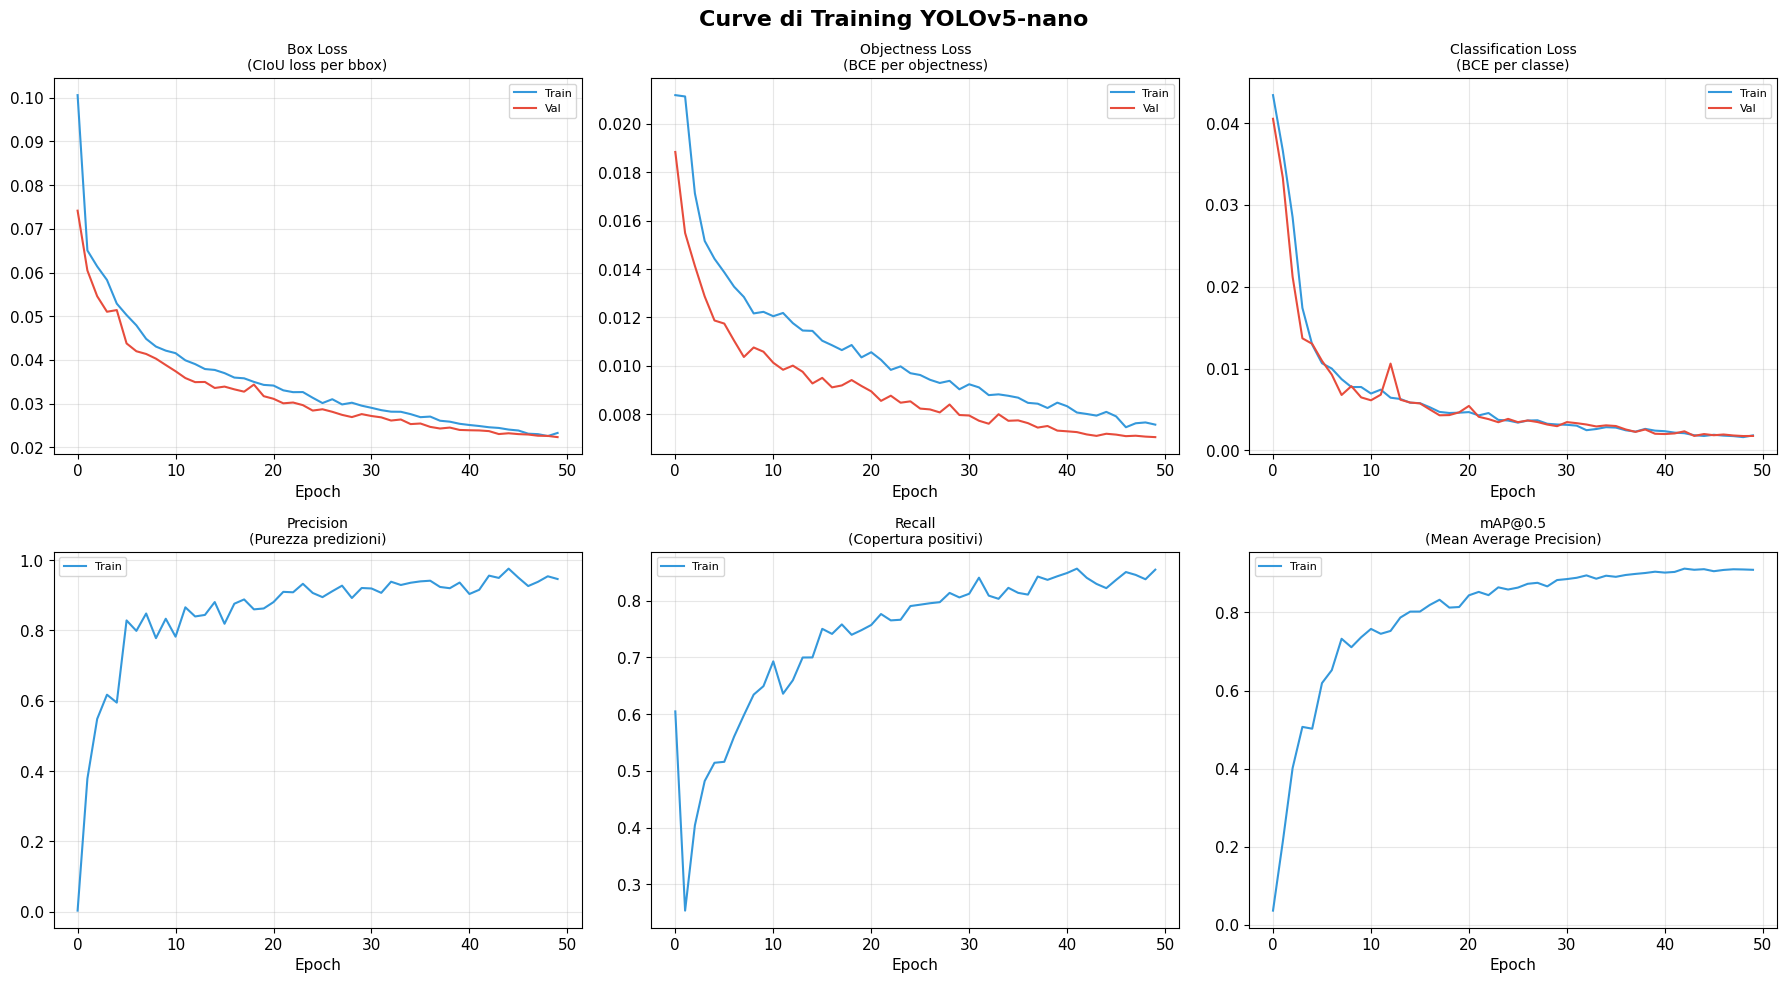


Migliori metriche (epoch 42) =>
mAP@0.5 => 0.9123
mAP@0.5:0.95 => 0.6748
Precision => 0.9559
Recall => 0.8402


In [22]:
%matplotlib inline
import pandas as pd

# yolov5 salva tutte le metriche epoca per epoca in un file CSV
# pandas e' la libreria per leggere e manipolare tabelle di dati
cartella_risultati = Path('runs/minecraft/mob_detector')
percorso_csv = cartella_risultati / 'results.csv'

if percorso_csv.exists():
    # pd.read_csv legge il CSV e lo trasforma in un DataFrame (una tabella)
    # skipinitialspace=True ignora gli spazi extra dopo le virgole
    dati = pd.read_csv(percorso_csv, skipinitialspace=True)
    # .str.strip() rimuove spazi dai nomi delle colonne (a volte ce ne sono di troppo)
    dati.columns = dati.columns.str.strip()

    # plt.subplots crea una griglia di grafici
    # 2 righe x 3 colonne = 6 grafici totali, uno per ogni metrica
    fig, assi = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Curve di Training YOLOv5-nano", fontsize=16, fontweight='bold')

    # definisco le 6 metriche da plottare
    # le prime 3 sono LOSS (errori) => piu basse = meglio
    # le ultime 3 sono METRICHE di performance => piu alte = meglio
    #
    # Box Loss => quanto sono precisi i rettangoli (usa CIoU, cioe quanto si sovrappongono)
    # Objectness Loss => quanto il modello e' sicuro che ci sia un oggetto li
    # Classification Loss => quanto indovina la classe giusta tra le 4
    # Precision => delle detection fatte, quante sono giuste? (purezza)
    # Recall => dei mob veri, quanti sono stati trovati? (copertura)
    # mAP@0.5 => media della precision su tutte le classi (con sovrapposizione minima del 50%)
    lista_metriche = [
        ('train/box_loss', 'val/box_loss', 'Box Loss', 'CIoU loss per bbox'),
        ('train/obj_loss', 'val/obj_loss', 'Objectness Loss', 'BCE per objectness'),
        ('train/cls_loss', 'val/cls_loss', 'Classification Loss', 'BCE per classe'),
        ('metrics/precision', None, 'Precision', 'Purezza predizioni'),
        ('metrics/recall', None, 'Recall', 'Copertura positivi'),
        ('metrics/mAP_0.5', None, 'mAP@0.5', 'Mean Average Precision'),
    ]

    for i in range(len(lista_metriche)):
        colonna_train, colonna_val, titolo, descrizione = lista_metriche[i]

        # calcolo la posizione nella griglia 2x3
        # i // 3 da la riga (divisione intera => 0,1,2 stanno in riga 0, poi 3,4,5 in riga 1)
        # i % 3 da la colonna (resto della divisione => cicla 0, 1, 2)
        riga = i // 3
        colonna = i % 3
        ax = assi[riga, colonna]

        # curva blu = training (come va sul dataset di allenamento)
        if colonna_train in dati.columns:
            ax.plot(dati[colonna_train], label='Train', color='#3498db', linewidth=1.5)

        # curva rossa = validazione (come va su immagini mai viste)
        # per precision, recall e mAP c'e' solo la curva di validazione
        if colonna_val is not None and colonna_val in dati.columns:
            ax.plot(dati[colonna_val], label='Val', color='#e74c3c', linewidth=1.5)

        ax.set_title(f"{titolo}\n({descrizione})", fontsize=10)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)  # griglia leggera per leggere meglio

    plt.tight_layout()  # aggiusta automaticamente gli spazi tra i grafici
    plt.show()

    # stampo le migliori metriche raggiunte durante il training
    # idxmax() trova l'indice (cioe l'epoca) dove il valore e' massimo
    if 'metrics/mAP_0.5' in dati.columns:
        epoca_migliore = dati['metrics/mAP_0.5'].idxmax()
        print(f"\nMigliori metriche (epoch {epoca_migliore}) =>")
        print(f"mAP@0.5 => {dati['metrics/mAP_0.5'].max():.4f}")
        if 'metrics/mAP_0.5:0.95' in dati.columns:
            print(f"mAP@0.5:0.95 => {dati['metrics/mAP_0.5:0.95'].max():.4f}")
        if 'metrics/precision' in dati.columns:
            print(f"Precision => {dati.loc[epoca_migliore, 'metrics/precision']:.4f}")
        if 'metrics/recall' in dati.columns:
            print(f"Recall => {dati.loc[epoca_migliore, 'metrics/recall']:.4f}")

else:
    # il CSV non esiste => probabilmente il training non e' stato ancora eseguito
    print("CSV dei results non trovato, verifica che tutte le sezioni sono state avviate in precedenza")

    # magari c'e' almeno l'immagine results.png che yolov5 genera automaticamente
    from IPython.display import Image, display
    percorso_png = cartella_risultati / 'results.png'
    if percorso_png.exists():
        print("Ho trovato results.png, la mostro")
        display(Image(filename=str(percorso_png), width=900))

Osservazioni sulle curve di training

Loss (riga superiore)

Le tre loss scendono in modo regolare sia per il train che per la validazione, e convergono verso valori molto simili. Questo indica che il modello sta imparando senza overfitting. Se ci fosse overfitting vedremmo la curva di validazione risalire mentre quella di training continua a scendere.

Le tre loss misurano errori diversi:
- Box Loss => misura quanto sono precisi i rettangoli predetti rispetto a quelli reali (posizione e dimensione del bounding box)
- Objectness Loss => misura quanto il modello è bravo a distinguere gli oggetti dallo sfondo (c'è un mob qui oppure no?)
- Classification Loss => misura quanto il modello è bravo a riconoscere la classe giusta (è un creeper, skeleton, spider o zombie?)

Nella Box Loss e nella Classification Loss le due curve (train e val) convergono quasi allo stesso valore finale. Nella Objectness Loss la curva di validazione rimane leggermente sotto quella di training, il che è del tutto normale.

---------------------------------------

Metriche (riga inferiore, epoch 42)

Una epoch significa che il modello ha visto tutte le 2068 immagini del dataset una volta. Quindi epoch 42 vuol dire che il modello ha scorso l'intero dataset 42 volte, migliorando un po' ad ogni passaggio.

- Precision 0.9559 => il 95.6% delle detection prodotte dal modello sono corrette (pochissimi falsi positivi)
- Recall 0.8402 => il modello trova l'84% dei mob realmente presenti nelle immagini (qualcuno ogni tanto gli sfugge)
- mAP@0.5 0.9123 => considerando tutte e 4 le classi insieme, il modello ha un'accuratezza media del 91.2% (con soglia IoU del 50%)
- mAP@0.5:0.95 0.6748 => con soglie IoU più rigide (dal 50% al 95%) la precisione scende al 67.5%, perché il modello deve posizionare i box in modo quasi perfetto

Le metriche salgono rapidamente nelle prime 10 epoche e poi si stabilizzano dopo l'epoca 35 circa, segno che il modello ha raggiunto la convergenza. Il transfer learning da COCO ha funzionato bene. Con solo 50 epoche e circa 2000 immagini, il modello riesce a rilevare i mob di Minecraft con ottima accuratezza.

Confusion Matrix (generata da YOLOv5) =>


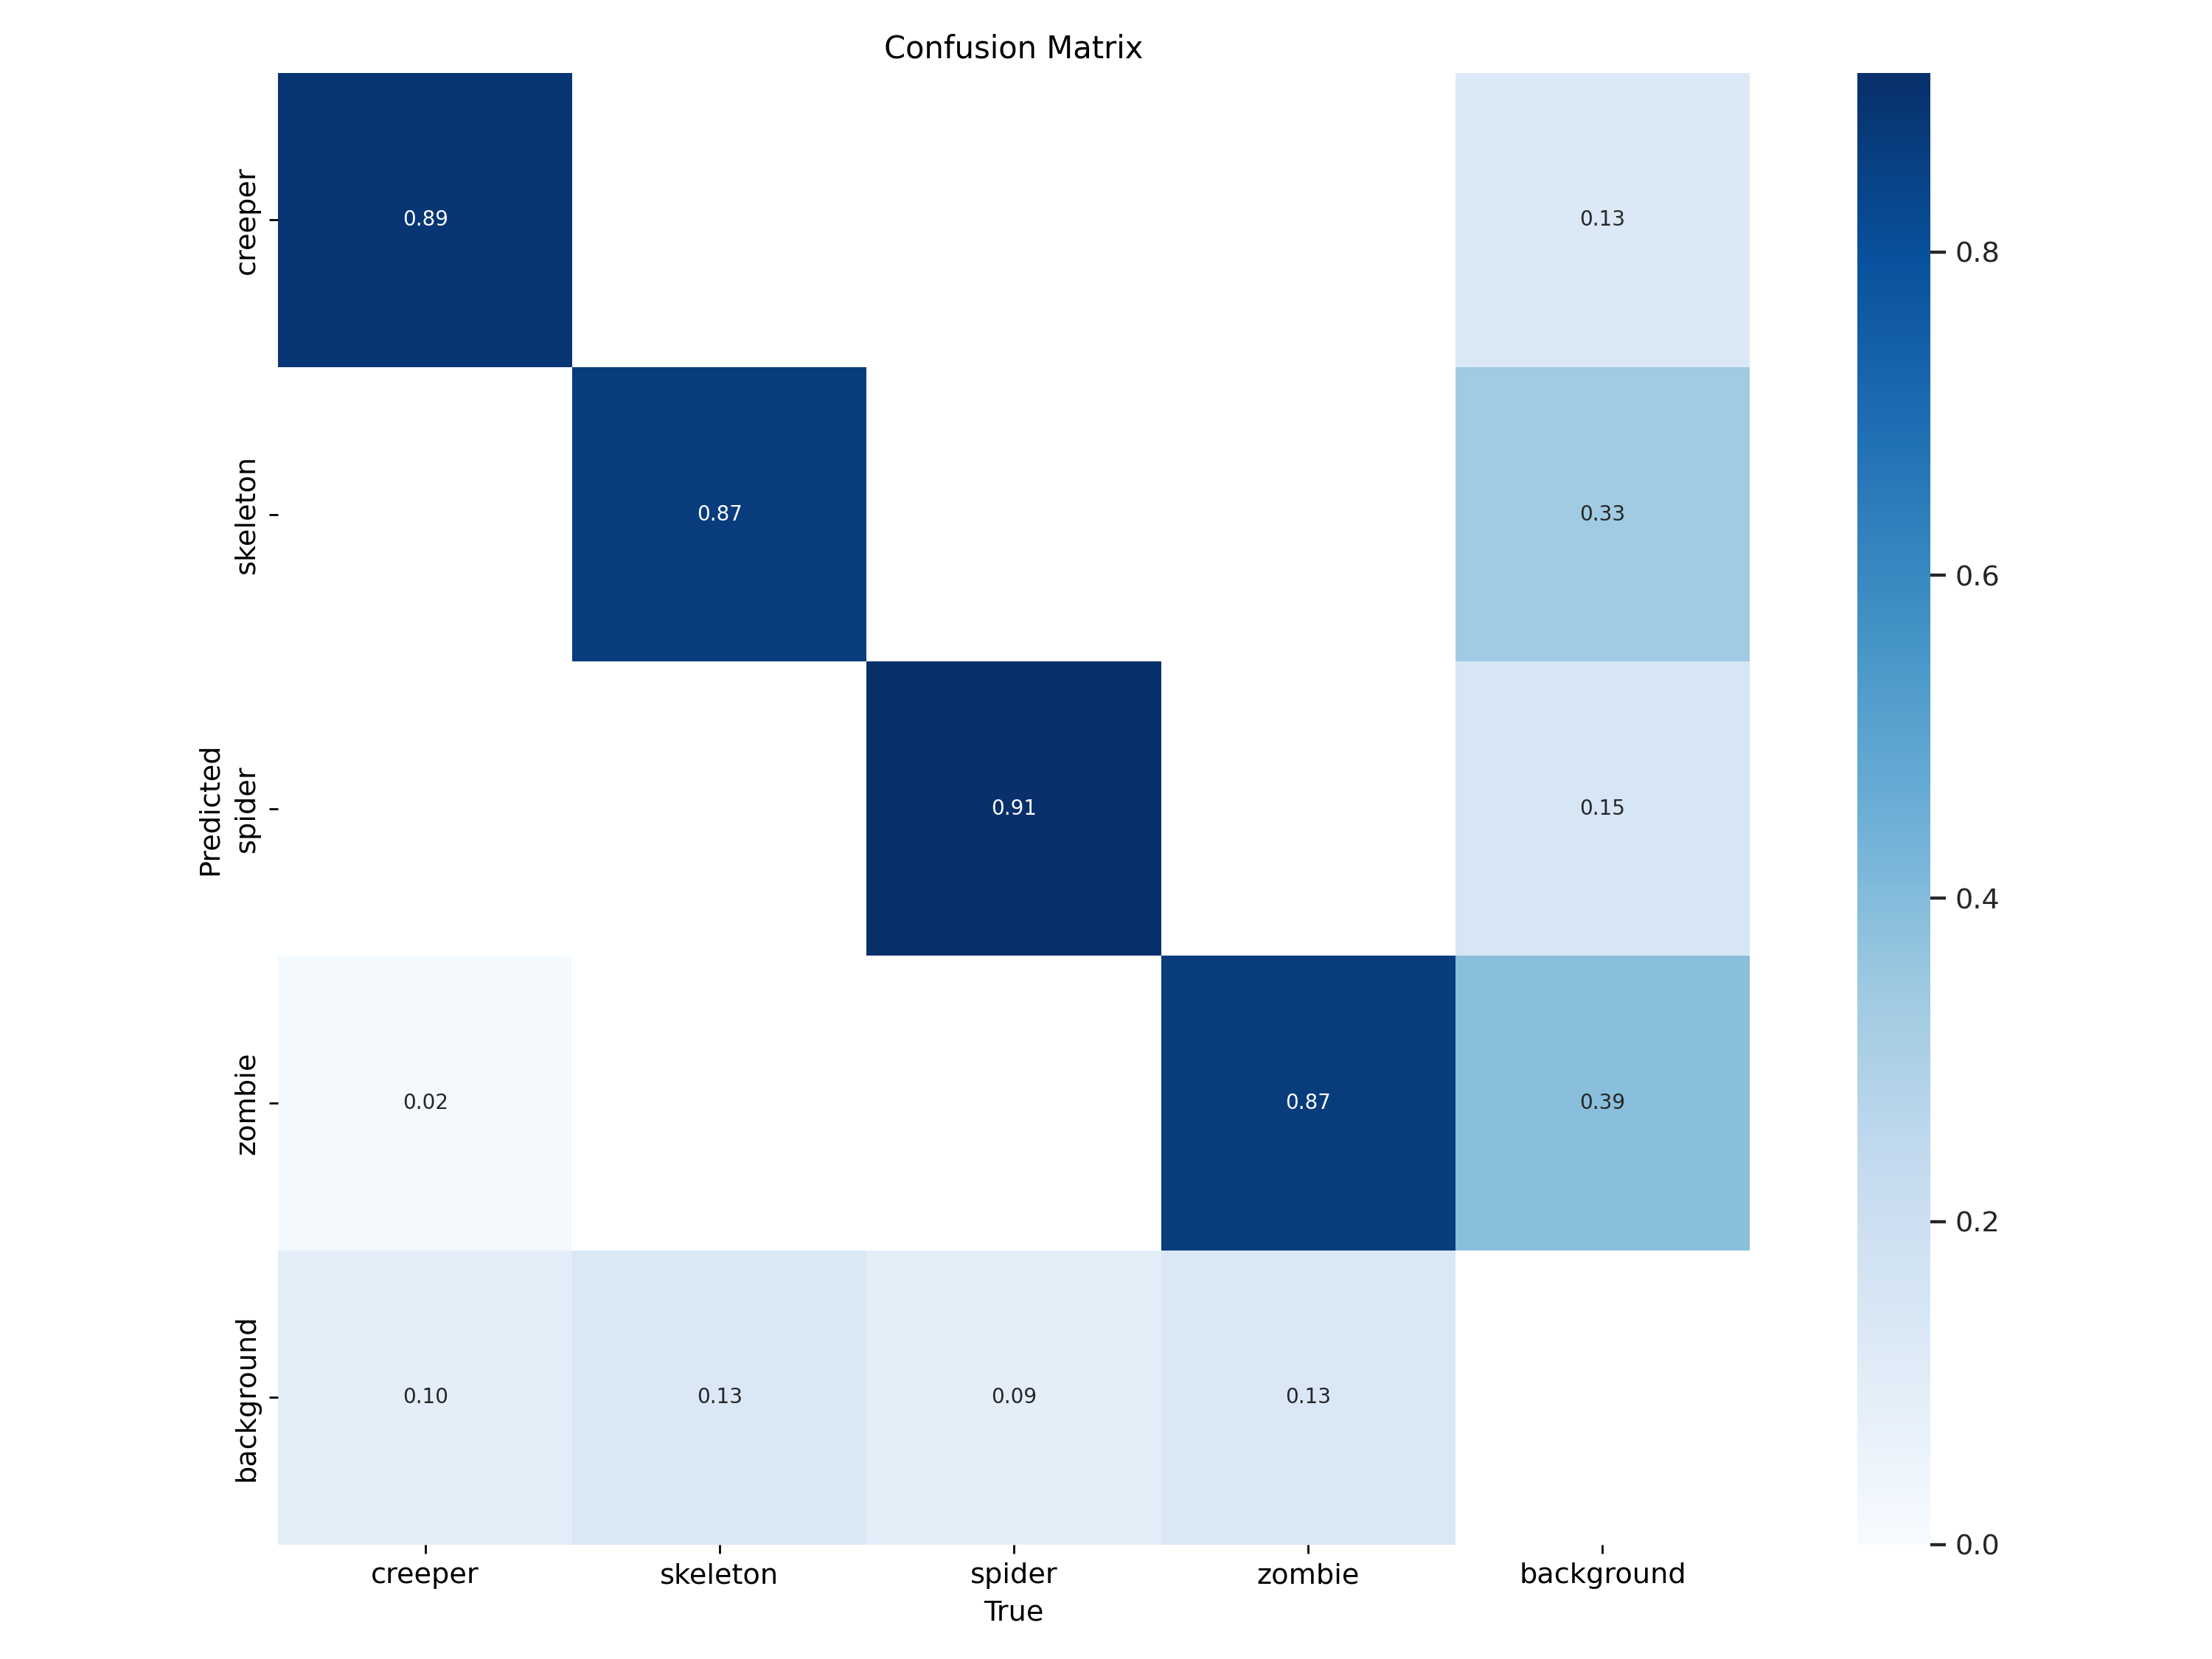

In [17]:
# la confusion matrix mostra gli errori del modello classe per classe
# e' una tabella dove:
# ogni riga rappresenta la classe REALE dell'oggetto
# ogni colonna rappresenta la classe PREDETTA dal modello
# i numeri sulla diagonale sono le predizioni CORRETTE
# i numeri fuori diagonale sono le CONFUSIONI tra classi
#
# esempio => se la cella (zombie, skeleton) ha un valore alto
# significa che il modello confonde spesso gli zombie con gli skeleton
# questo puo succedere perche hanno forme simili (umanoidi)

from IPython.display import Image, display

# yolov5 genera la confusion matrix automaticamente durante la validazione
percorso_matrice = cartella_risultati / 'confusion_matrix.png'

if percorso_matrice.exists():
    # il file esiste gia => lo mostro
    print("Confusion Matrix (generata da YOLOv5) =>")
    display(Image(filename=str(percorso_matrice), width=600))
else:
    # il file non esiste => lancio lo script di validazione per generarlo
    # val.py e' lo script di yolov5 che valuta il modello sul set di validazione
    print("Genero la confusion matrix con la validazione...")
    !python val.py \
        --data minecraft_mobs.yaml \
        --weights runs/minecraft/mob_detector/weights/best.pt \
        --img 640 \
        --task test \
        --project runs/minecraft \
        --name val_results \
        --exist-ok \
        --save-json \
        --verbose

    # provo a mostrare la matrice appena generata
    percorso_matrice = Path('runs/minecraft/val_results/confusion_matrix.png')
    if percorso_matrice.exists():
        display(Image(filename=str(percorso_matrice), width=600))

## 6. Inferenza sulla detection su immagini di test (REVISIONATO)

L'inferenza e' il momento in cui usiamo il modello gia' allenato per fare predizioni su immagini nuove. Non c'e' nessun apprendimento in questa fase, il modello usa solo quello che ha imparato durante il training.

Quindi qua faccio una validazione rapida con poche immagini per vedere come si comporta il modello allenato.

La pipeline di Object Detection funziona in tre passaggi:

1. Pre-processing => prima di entrare nella rete, l'immagine viene preparata. Viene ridimensionata a 640x640 pixel (la dimensione che il modello si aspetta), i valori dei pixel vengono normalizzati da 0-255 a 0-1 (cosi' la rete lavora con numeri piccoli e stabili), e i canali di colore vengono convertiti da BGR (il formato di OpenCV) a RGB (il formato standard). YOLOv5 usa anche il "letterbox padding", cioe' aggiunge bande nere ai lati per mantenere le proporzioni originali senza deformare l'immagine.

2. Forward pass => l'immagine preparata attraversa tutta la rete in un colpo solo. Passa prima nel backbone (che estrae le feature), poi nel neck (che le fonde a diverse risoluzioni), e infine nella head (che produce le predizioni).

A differenza della pipeline classica HOG+SVM che deve scorrere centinaia di finestre sull'immagine a diverse scale, YOLO processa l'intera immagine in un unico passaggio. Per questo e' molto piu' veloce.

3. Post-processing => la rete produce migliaia di possibili detection, la maggior parte con confidenza bassissima. Prima vengono filtrate tutte quelle sotto la soglia di confidenza (nel nostro caso 0.4, cioe' il modello deve essere almeno sicuro al 40%). Poi la NMS (Non-Maximum Suppression) elimina i box duplicati che si sovrappongono troppo, tenendo solo quello con la confidenza piu' alta. Il risultato finale e' una lista pulita di detection, ognuna con le coordinate del box, la classe predetta e il livello di confidenza.

Con YOLOv5 tutta questa pipeline e' automatica. l framework fa tutto internamente, dal resize alla NMS.

In [18]:
# carico il modello migliore salvato durante il training
# yolov5 salva due file di pesi
# best.pt => i pesi dell'epoca con il mAP piu alto (il modello migliore)
# last.pt => i pesi dell'ultima epoca (utile come backup)
# noi usiamo best.pt perche e' il piu accurato
percorso_pesi = cartella_risultati / 'weights' / 'best.pt'

# torch.hub.load scarica e carica un modello pytorch
# 'custom' dice a yolov5 di usare i nostri pesi personalizzati (non quelli originali COCO)
# force_reload=True forza il ricaricamento anche se il modello e' gia in cache
modello = torch.hub.load('ultralytics/yolov5', 'custom',
                          path=str(percorso_pesi), force_reload=True)

# conf = soglia di confidenza => mostra solo detection con confidenza >= 40%
# se la abbasso vedo piu detection ma anche piu falsi positivi (oggetti inventati)
# se la alzo vedo meno detection ma quelle che rimangono sono piu affidabili
modello.conf = 0.4

# iou = soglia per la Non-Maximum Suppression (NMS)
# quando il modello trova lo stesso oggetto piu volte con box sovrapposti,
# NMS tiene solo il box con la confidenza piu alta e scarta gli altri
# 0.45 significa => se due box si sovrappongono per piu del 45%, elimino il peggiore
modello.iou = 0.45

print(f"Modello caricato => {percorso_pesi}")
print(f"Soglia confidenza => {modello.conf}")
print(f"Soglia NMS IoU => {modello.iou}")

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 v7.0-506-g0675a31b Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 1764577 parameters, 0 gradients, 4.1 GFLOPs
Adding AutoShape... 


Modello caricato => runs/minecraft/mob_detector/weights/best.pt
Soglia confidenza => 0.4
Soglia NMS IoU => 0.45


- Fusing layers => YOLOv5 unisce alcuni layer adiacenti (ad esempio Conv + BatchNorm) in un unico layer. Non cambia niente nei risultati, serve solo a rendere l'inferenza più veloce. È un'ottimizzazione automatica.

- 157 layers => il modello finale ha 157 layer dopo il fusing.

- 1,764,577 parameters => quanti pesi ha il modello. È leggermente diverso dai 1,867,405 di prima perché quelli erano del modello originale COCO (80 classi), questo è quello adattato alle nostre 4 classi. La head ha meno neuroni.

- 0 gradients => conferma che il modello è in modalità inferenza, i gradienti sono spenti.

- 4.1 GFLOPs => quante operazioni matematiche servono per processare una singola immagine. Più è basso, più il modello è veloce. 4.1 GFLOPs è molto poco (ResNet50 ne fa circa 4 miliardi in più).

- Adding AutoShape => YOLOv5 aggiunge un wrapper che gestisce automaticamente il preprocessing (resize, conversione colori, normalizzazione). Grazie a questo puoi passare un'immagine qualsiasi con modello(immagine) senza doverti preoccupare di ridimensionarla a 640x640.

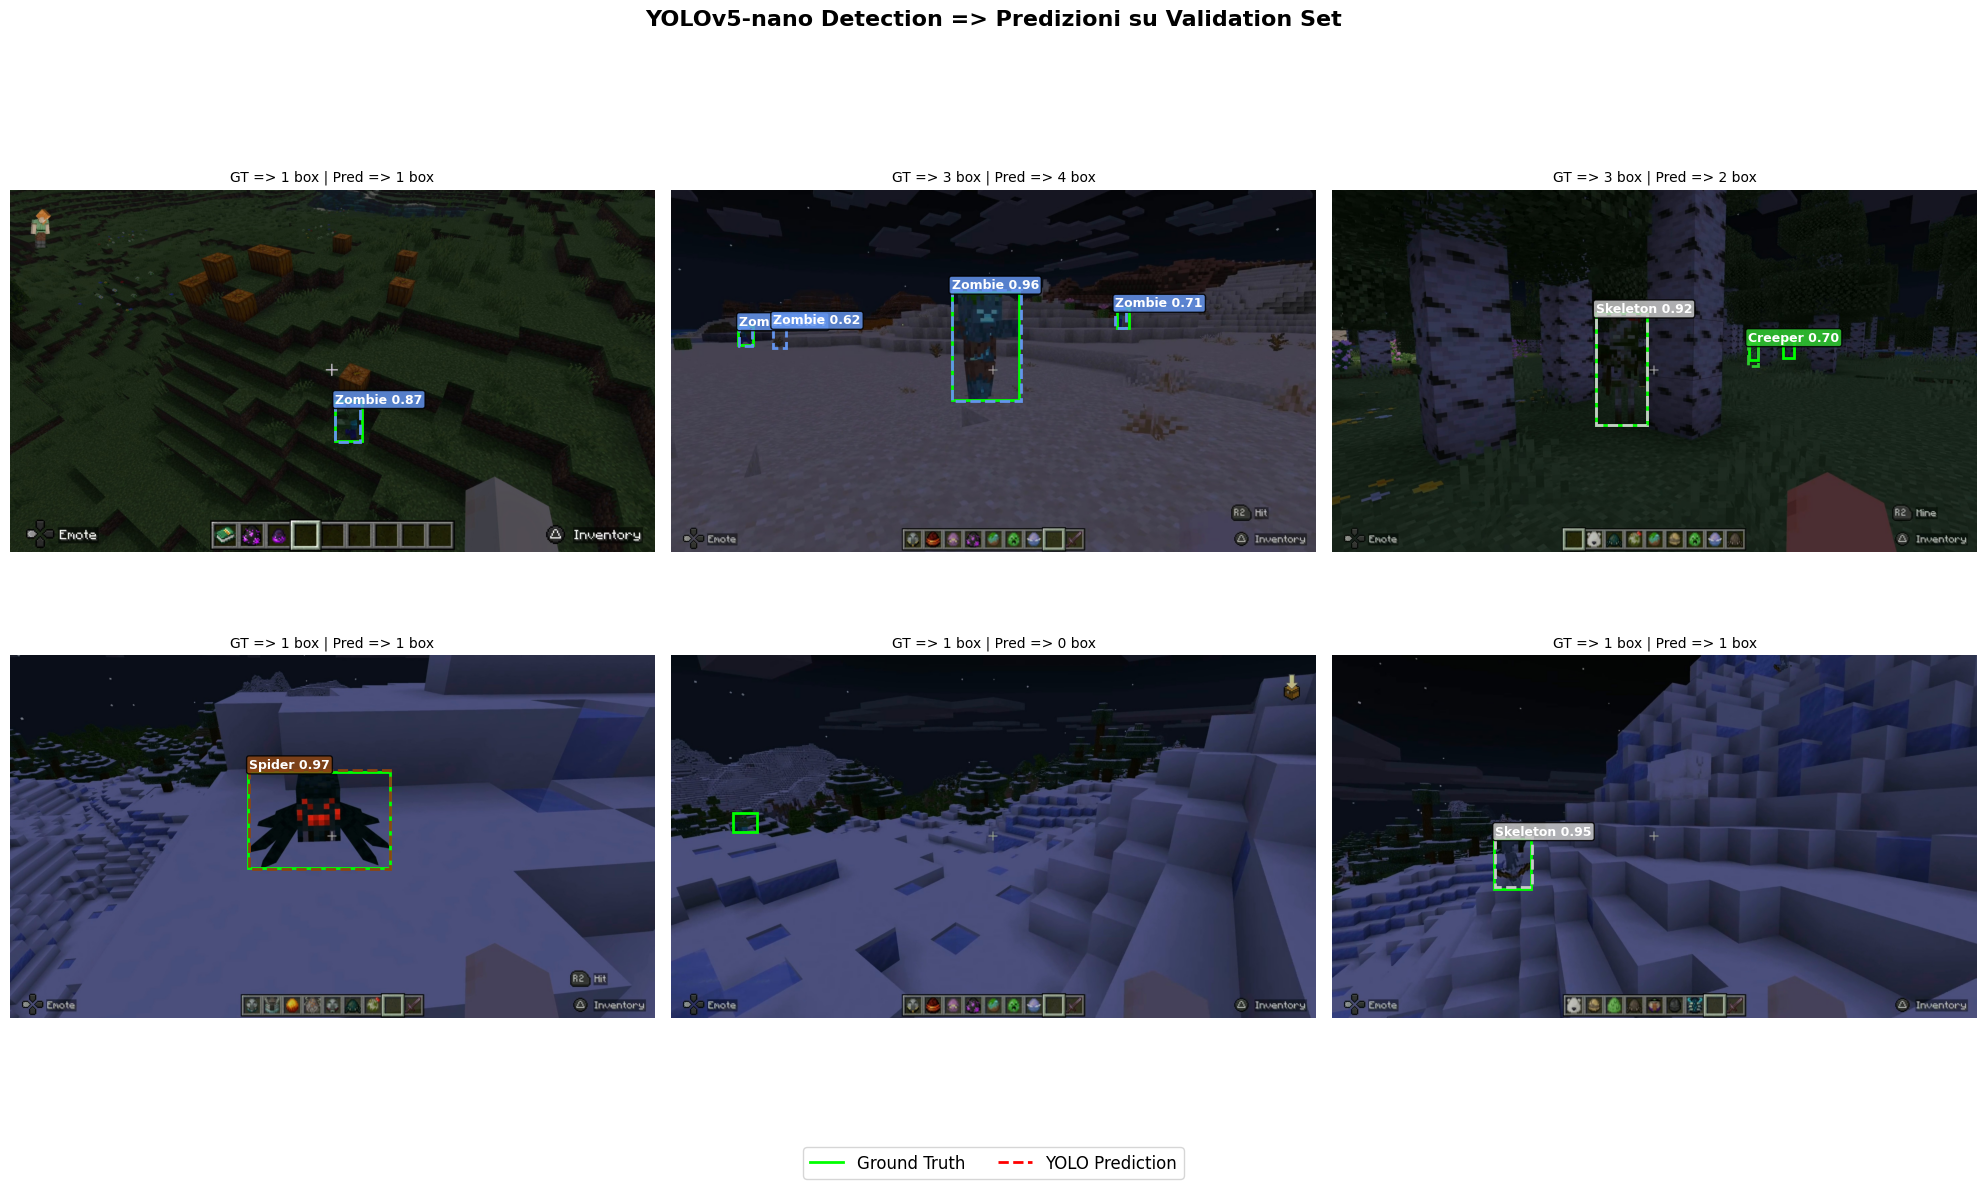

In [19]:
%matplotlib inline
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import warnings
# FutureWarning sono avvisi di pytorch su funzioni che cambieranno in futuro
# non sono errori, ma riempiono l'output di testo inutile => li nascondo
warnings.filterwarnings("ignore", category=FutureWarning)

# dizionario che mappa ogni id numerico al nome della classe corrispondente
nomi_classi = {0: "Creeper", 1: "Skeleton", 2: "Spider", 3: "Zombie"}

# colori RGB (valori da 0 a 1) per distinguere le classi nei grafici
colori_classi = {
    0: (0.18, 0.8, 0.18),   # verde per creeper
    1: (0.78, 0.78, 0.78),  # grigio per skeleton
    2: (0.55, 0.27, 0.07),  # marrone per spider
    3: (0.39, 0.58, 0.93),  # blu per zombie
}


def leggi_etichette(percorso_etichetta):
    # Questa funzione legge un file di annotazioni YOLO e ritorna la lista dei bounding box
    #
    # Ogni riga del file ha il formato =>
    #   classe  x_centro  y_centro  larghezza  altezza
    # Tutti i valori sono normalizzati tra 0 e 1 (relativi alla dimensione dell'immagine)
    # Esempio => "3 0.5 0.4 0.2 0.3" vuol dire uno zombie al centro dell'immagine

    lista_box = []
    percorso = Path(percorso_etichetta)

    # se il file non esiste ritorno una lista vuota
    if not percorso.exists():
        return lista_box

    # leggo l'intero contenuto del file come una stringa
    contenuto = percorso.read_text().strip()
    if contenuto == "":
        return lista_box

    # separo il testo in righe (ogni riga = un bounding box)
    righe = contenuto.split("\n")
    for riga in righe:
        # split() divide la stringa per spazi
        # "3 0.5 0.4 0.2 0.3" diventa ["3", "0.5", "0.4", "0.2", "0.3"]
        parti = riga.strip().split()
        if len(parti) == 5:
            classe = int(parti[0])           # id della classe (0, 1, 2 o 3)
            x_centro = float(parti[1])       # coordinata x del centro del box
            y_centro = float(parti[2])       # coordinata y del centro del box
            larghezza = float(parti[3])      # larghezza del box
            altezza = float(parti[4])        # altezza del box
            lista_box.append((classe, x_centro, y_centro, larghezza, altezza))

    return lista_box


# glob cerca tutti i file che corrispondono al pattern
# *.jpg = tutti i file che finiscono con .jpg
lista_immagini_val = sorted(
    list(cartella_immagini_val.glob("*.jpg")) + list(cartella_immagini_val.glob("*.png"))
)

# filtro solo le immagini che hanno almeno un bounding box annotato
# (alcune immagini sono "background" => solo sfondo senza mob)
immagini_con_annotazioni = []
for file_img in lista_immagini_val:
    # file_img.stem e' il nome del file senza estensione
    # esempio => "img_042.jpg" ha stem "img_042"
    # cerco il file .txt con lo stesso nome nella cartella labels
    percorso_etichetta = cartella_etichette_val / (file_img.stem + ".txt")
    box_trovati = leggi_etichette(percorso_etichetta)
    if len(box_trovati) > 0:
        immagini_con_annotazioni.append((file_img, percorso_etichetta))

# scelgo 6 immagini casuali da visualizzare
# random.seed(42) fissa il generatore casuale => ogni volta ottengo le stesse 6 immagini
# cosi il risultato e' riproducibile
random.seed(42)
numero_campioni = min(6, len(immagini_con_annotazioni))
campioni = random.sample(immagini_con_annotazioni, numero_campioni)

# creo una griglia 2x3 (2 righe, 3 colonne = 6 immagini)
fig, assi = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("YOLOv5-nano Detection => Predizioni su Validation Set",
             fontsize=16, fontweight='bold')

for indice in range(len(campioni)):
    percorso_img, percorso_lbl = campioni[indice]

    # calcolo la posizione nella griglia
    riga = indice // 3     # divisione intera => 0,1,2 vanno in riga 0 e 3,4,5 in riga 1
    colonna = indice % 3   # resto della divisione => cicla 0, 1, 2
    ax = assi[riga, colonna]

    # opencv legge le immagini in formato BGR (blu, verde, rosso)
    # matplotlib invece vuole il formato RGB => devo convertire
    immagine_bgr = cv2.imread(str(percorso_img))
    immagine_rgb = cv2.cvtColor(immagine_bgr, cv2.COLOR_BGR2RGB)
    # .shape ritorna (altezza, larghezza, canali) => prendo solo i primi due valori
    altezza_img, larghezza_img = immagine_bgr.shape[:2]
    ax.imshow(immagine_rgb)  # mostro l'immagine nel subplot

    # GROUND TRUTH (linea continua verde)
    # il ground truth e' la "verita" => le annotazioni fatte a mano da un umano
    box_reali = leggi_etichette(percorso_lbl)
    for box in box_reali:
        classe_id, xc, yc, bw, bh = box
        # le coordinate YOLO sono normalizzate (da 0 a 1)
        # per disegnarle devo convertirle in pixel moltiplicando per le dimensioni
        # YOLO usa il CENTRO del box, ma Rectangle vuole l'angolo in ALTO A SINISTRA
        x1 = int((xc - bw / 2) * larghezza_img)   # bordo sinistro
        y1 = int((yc - bh / 2) * altezza_img)      # bordo superiore
        w_pixel = int(bw * larghezza_img)            # larghezza in pixel
        h_pixel = int(bh * altezza_img)              # altezza in pixel
        rettangolo = patches.Rectangle(
            (x1, y1), w_pixel, h_pixel,
            linewidth=2, edgecolor='lime', facecolor='none'  # bordo verde, nessun riempimento
        )
        ax.add_patch(rettangolo)  # aggiungo il rettangolo al grafico

    # PREDIZIONI YOLO (linea tratteggiata colorata)
    # passo l'immagine al modello e ottengo le detection
    risultati = modello(immagine_rgb)
    # .xyxy[0] contiene i box in formato [x1, y1, x2, y2, confidenza, classe]
    # (x1,y1) = angolo alto-sinistra, (x2,y2) = angolo basso-destra
    # .cpu() sposta i dati dalla GPU alla CPU
    # .numpy() converte il tensore pytorch in un array numpy
    predizioni = risultati.xyxy[0].cpu().numpy()

    for pred in predizioni:
        x1, y1, x2, y2, confidenza, classe_pred = pred
        classe_pred = int(classe_pred)
        # .get() cerca la chiave nel dizionario, se non la trova usa il valore di default
        colore = colori_classi.get(classe_pred, (1, 1, 1))  # bianco come default

        # disegno il box predetto con linea tratteggiata per distinguerlo dal ground truth
        rettangolo = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=colore, facecolor='none', linestyle='--'
        )
        ax.add_patch(rettangolo)

        # scrivo il nome della classe e la confidenza sopra il box
        # :.2f formatta il numero con 2 decimali (esempio => 0.89)
        nome = nomi_classi.get(classe_pred, '?')
        ax.text(x1, y1 - 5, f"{nome} {confidenza:.2f}",
                fontsize=9, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=colore, alpha=0.85))

    # nel titolo mostro quanti box reali ci sono e quanti ne ha predetto il modello
    ax.set_title(f"GT => {len(box_reali)} box | Pred => {len(predizioni)} box", fontsize=10)
    ax.axis('off')  # nascondo gli assi numerici (non servono per le immagini)

# legenda per spiegare il significato dei colori delle linee
elementi_legenda = [
    Line2D([0], [0], color='lime', lw=2, label='Ground Truth'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='YOLO Prediction'),
]
fig.legend(handles=elementi_legenda, loc='lower center', ncol=2, fontsize=12)

# rect=[0, 0.03, 1, 0.97] lascia un po' di spazio in basso per la legenda
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [23]:
# best.pt e' il file piu importante => contiene i pesi del modello pronto all'uso
# lo copio in una posizione comoda cosi e' facile da trovare
percorso_pesi_migliori = cartella_risultati / 'weights' / 'best.pt'

if percorso_pesi_migliori.exists():
    # copio il file nella cartella principale del progetto
    shutil.copy(percorso_pesi_migliori, 'best_minecraft.pt')
    # .stat().st_size ritorna la dimensione in bytes
    # divido per 1e6 (un milione) per convertire in megabytes
    dimensione_mb = percorso_pesi_migliori.stat().st_size / 1e6
    print(f"Modello migliore copiato => best_minecraft.pt")
    print(f"   Dimensione => {dimensione_mb:.1f} MB")

# su google colab i file si cancellano quando il runtime si disconnette
# salvando su google drive i pesi restano anche dopo la disconnessione
# try/except => se il codice dentro "try" da errore, esegue "except" senza bloccarsi
try:
    from google.colab import drive
    # mount collega il tuo google drive al filesystem di colab
    drive.mount('/content/drive', force_remount=False)
    # creo la cartella di destinazione
    # parents=True crea anche le cartelle intermedie se non esistono
    # exist_ok=True non da errore se la cartella c'e' gia
    cartella_drive = Path('/content/drive/MyDrive/minecraft_mob_detector')
    cartella_drive.mkdir(parents=True, exist_ok=True)
    shutil.copy(percorso_pesi_migliori, cartella_drive / 'best_minecraft.pt')
    print(f"Modello salvato anche su Google Drive => {cartella_drive}")
except:
    # non siamo su colab oppure drive non e' disponibile => non e' un problema
    print("Google Drive non disponibile, salvataggio solo locale.")

Modello migliore copiato => best_minecraft.pt
   Dimensione => 3.8 MB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modello salvato anche su Google Drive => /content/drive/MyDrive/minecraft_mob_detector


## Conclusione

Il fine-tuning di YOLOv5-nano sul dataset Minecraft Mobs ha prodotto ottimi risultati. Il training ha completato 50 epoche in circa 32 minuti su una GPU Tesla T4 con 2068 immagini di training e 517 di validazione.

Le migliori metriche sono state raggiunte all'epoca 42:

- Precision 0.9559 => il 95.6% delle detection prodotte dal modello sono corrette (pochissimi falsi positivi)
- Recall 0.8402 => il modello trova l'84% dei mob realmente presenti nelle immagini
- mAP@0.5 0.9123 => accuratezza media del 91.2% su tutte e 4 le classi con soglia IoU al 50%
- mAP@0.5:0.95 0.6748 => con soglie IoU piu' rigide (dal 50% al 95%) la precisione scende al 67.5%

Le curve di training mostrano che non c'e' overfitting => le loss di train e validazione scendono insieme e convergono verso valori simili. Le metriche si stabilizzano dopo l'epoca 35 circa, segno che il modello ha raggiunto la convergenza.

Il modello finale pesa solo 3.8 MB, molto leggero rispetto ad altre architetture (VGG16 supera i 500 MB). Il transfer learning da COCO ha funzionato bene: partendo da un modello gia' esperto su 80 classi di oggetti generici, bastano 50 epoche e circa 2000 immagini per adattarlo a un dominio completamente diverso come Minecraft.

La sezione di inferenza visiva conferma i risultati numerici => il modello riesce a individuare e classificare correttamente i mob nella maggior parte dei casi, con qualche errore sporadico sugli oggetti piccoli o parzialmente nascosti.